# Input and output formats

`sfsutils` reads variants from a VCF file, a VCF-Zarr store, or a tskit tree sequence (an ARG) through a
single streamed site interface, so the same analysis code works regardless of the input format. The
filterer and annotator write their result back in the format implied by the output file's extension.

The dataset used here is a synthetic ARG, provided as a tree sequence together with the VCF and VCF-Zarr
store converted from it. Because all three encode the same genotypes, they yield the same spectrum.

In [1]:
import os, tempfile, shutil
import numpy as np
from sfsutils.settings import Settings

Settings.disable_pbar = True
_root = os.getcwd()
_resources = os.path.join(_root, 'resources', 'msprime')
_work = tempfile.mkdtemp()
for _name in ('two_epoch.trees', 'two_epoch.vcf'):
    shutil.copy(os.path.join(_resources, _name), _work)
shutil.copytree(os.path.join(_resources, 'two_epoch.vcz'), os.path.join(_work, 'two_epoch.vcz'))
os.chdir(_work)

## The same dataset in three forms

In [2]:
trees = 'two_epoch.trees'  # tskit tree sequence (the ARG)
vcf   = 'two_epoch.vcf'    # VCF written from it
vcz   = 'two_epoch.vcz'    # VCF-Zarr store converted from the VCF

## Reading: one interface, three backends

`Parser` accepts any of the three as its `vcf` argument and infers the backend from the source. Reading a
VCF-Zarr store needs the optional `zarr` package, a tree sequence the optional `tskit` package.

In [3]:
import sfsutils as su

kw = dict(n=20, skip_non_polarized=False)
sfs_trees = su.Parser(vcf=trees, **kw).parse()
sfs_vcf   = su.Parser(vcf=vcf,   **kw).parse()
sfs_vcz   = su.Parser(vcf=vcz,   **kw).parse()

# the three spectra are identical
np.allclose(sfs_trees.all.to_list(), sfs_vcf.all.to_list()) and \
    np.allclose(sfs_vcf.all.to_list(), sfs_vcz.all.to_list())

INFO:Parser: Using stratification: [all].
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the VCF file.
INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the VCF file.
INFO:Parser: Using stratification: [all].
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the VCF file.


True

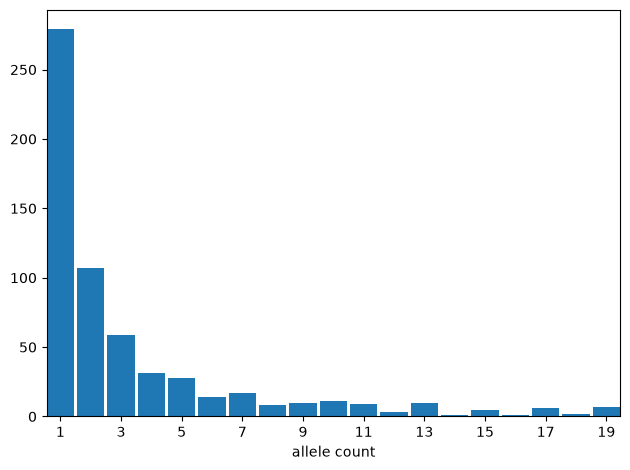

In [4]:
sfs_vcf.all.plot();

## Writing: the output format follows the file extension

`Filterer` and `Annotator` pick the writer from the output file's extension: `.vcf`/`.vcf.gz` for a VCF,
`.vcz`/`.zarr` for a VCF-Zarr store, and `.trees` for a tree sequence.

In [5]:
# a VCF-Zarr store can be written from any input
su.Filterer(vcf=vcf, output='snps.vcz', filtrations=[su.SNPFiltration()]).filter()

# a VCF is written from a VCF input as before
su.Filterer(vcf=vcf, output='snps.vcf', filtrations=[su.SNPFiltration()]).filter()

INFO:Filterer: Start filtering
INFO:Filterer: Loading VCF file
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.
INFO:Filterer: Start filtering
INFO:Filterer: Loading VCF file
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.


A tree sequence can only be written from a tree-sequence input: filtering removes the discarded sites with
`delete_sites`, leaving the genealogy intact. A genealogy cannot be reconstructed from genotype data, so
writing a `.trees` from a VCF or VCF-Zarr store is rejected.

In [6]:
su.Filterer(vcf=trees, output='snps.trees', filtrations=[su.SNPFiltration()]).filter()

# the written store and tree sequence parse back to the same spectrum as the VCF output
back = {f: su.Parser(vcf=f, **kw).parse().all.to_list() for f in ('snps.vcf', 'snps.vcz', 'snps.trees')}
all(np.allclose(v, back['snps.vcf']) for v in back.values())

INFO:Filterer: Start filtering
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.
INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the VCF file.
INFO:Parser: Using stratification: [all].
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the VCF file.
INFO:Parser: Using stratification: [all].
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the VCF file.


True

In [7]:
os.chdir(_root)
shutil.rmtree(_work, ignore_errors=True)